# Multiple lineare Regression zur Erklärung des Basispreises (USD)

## Ziel der multiplen Regression
Ziel dieses Notebooks ist die Untersuchung der Einflussfaktoren auf den Basispreis (USD) mittels multipler linearer Regression. Im Gegensatz zum Regressionsbaum steht hier die ökonomische Interpretierbarkeit der Koeffizienten im Vordergrund.


## Setup
### Imports, Pfade und Helper

In [1]:
%matplotlib inline

from pathlib import Path
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Pfade für In- und Output definieren
ROOT = Path.cwd()

INPUT_RAW = ROOT / "input" / "raw"
INPUT_PROCESSED = ROOT / "input" / "processed"

OUT = ROOT / "output"
FIG_DIR = OUT / "figures"

FIG_MR = FIG_DIR / "modeling" / "multiple_regression"
FIG_MR.mkdir(parents=True, exist_ok=True)

for p in [INPUT_RAW, INPUT_PROCESSED, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATA_FILE = INPUT_PROCESSED / "mercedes_sales_processed.csv"

# Helper-Funktion für saubere Dateinamen
def _slugify(text: str) -> str:
    text = (text or "").strip()
    text = re.sub(r"[^\w\s-]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text if text else "Plot"

# Klasse zur Verwaltung und Speicherung der Plots mit fortlaufender Nummerierung
class PlotSaverMR:
    def __init__(self, fig_dir: Path):
        self.fig_dir = fig_dir
        self.counter = self._next_plot_number()

    def _next_plot_number(self) -> int:
        pattern = re.compile(r"^(\d{2,})\s+.*\.png$", re.IGNORECASE)
        nums = []
        for p in self.fig_dir.glob("*.png"):
            m = pattern.match(p.name)
            if m:
                nums.append(int(m.group(1)))
        return (max(nums) + 1) if nums else 1

    def __call__(self, dpi: int = 120):
        fig = plt.gcf()
        if fig is None or len(fig.axes) == 0:
            print("Kein Plot zum Speichern")
            return

        title = plt.gca().get_title() or "plot"
        slug = _slugify(title)

        # Prüfen, ob Datei mit diesem Titel existiert
        existing = list(self.fig_dir.glob(f"* {slug}.png"))
        if existing:
            print(f"Übersprungen (Titel existiert bereits): {existing[0].name}")
            return

        filename = f"{self.counter:02d} {slug}.png"
        filepath = self.fig_dir / filename

        fig.tight_layout()
        fig.savefig(filepath, dpi=dpi, bbox_inches="tight")
        print(f"Gespeichert: {filepath.name}")

        # Zähler für den nächsten Aufruf erhöhen
        self.counter += 1

# Initialisierung der Speicher-Funktion
save_current_plot_mr = PlotSaverMR(FIG_MR)

## Datenbasis

In [2]:
# Bereinigte Daten laden und prüfen
df = pd.read_csv(DATA_FILE)

print("Shape:", df.shape)
df.head()

Shape: (12129513, 7)


,Model,Year,Color,Fuel Type,Base Price (USD),Horsepower,Turbo
0,A-Class,2020,Yellow,Diesel,41265,252,Yes
1,A-Class,2020,Black,Petrol,51023,249,No
2,A-Class,2020,Grey,Petrol,72819,341,Yes
3,A-Class,2020,Black,Petrol,62480,385,Yes
4,A-Class,2020,White,Petrol,35189,337,Yes


In [3]:
# Grundlegende Infos und Unterteilung in numerische/kategoriale Spalten
print("\nGrundlegende Informationen:")
df.info()

numeric_columns = df.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = df.select_dtypes(exclude=["number"]).columns.tolist()

print(f"\nNumerische Spalten ({len(numeric_columns)}): {numeric_columns}")
print(f"Kategoriale Spalten ({len(categorical_columns)}): {categorical_columns}")
print(f"\nDatensatzgröße: {df.shape[0]} Zeilen und {df.shape[1]} Spalten")


Grundlegende Informationen:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12129513 entries, 0 to 12129512
Data columns (total 7 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   Model             object
 1   Year              int64 
 2   Color             object
 3   Fuel Type         object
 4   Base Price (USD)  int64 
 5   Horsepower        int64 
 6   Turbo             object
dtypes: int64(3), object(4)
memory usage: 647.8+ MB

Numerische Spalten (3): ['Year', 'Base Price (USD)', 'Horsepower']
Kategoriale Spalten (4): ['Model', 'Color', 'Fuel Type', 'Turbo']

Datensatzgröße: 12129513 Zeilen und 7 Spalten


In [4]:
# Zielvariable umbenennen für einfacheres Handling
df = df.rename(columns={
    "Base Price (USD)": "Base_USD",
    "Fuel Type": "Fuel_Type"
})

# Turbo-Merkmal in binäre Werte umwandeln
df["Turbo_bin"] = (df["Turbo"] == "Yes").astype("int8")
display(pd.crosstab(df["Turbo"], df["Turbo_bin"]))

# Datentypen anpassen, um RAM-Speicher zu sparen
cat_cols = ["Model", "Color", "Fuel_Type", "Turbo"]
for col in cat_cols:
    df[col] = df[col].astype("category")

df["Year"] = df["Year"].astype("int16")
df["Horsepower"] = df["Horsepower"].astype("int16")
df["Base_USD"] = df["Base_USD"].astype("int32")

df.info(memory_usage="deep")

Turbo_bin,0,1
Turbo,,
No,1761277,0
Yes,0,10368236


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12129513 entries, 0 to 12129512
Data columns (total 8 columns):
 #   Column      Dtype   
---  ------      -----   
 0   Model       category
 1   Year        int16   
 2   Color       category
 3   Fuel_Type   category
 4   Base_USD    int32   
 5   Horsepower  int16   
 6   Turbo       category
 7   Turbo_bin   int8    
dtypes: category(4), int16(2), int32(1), int8(1)
memory usage: 150.4 MB


## Modellierung

In [5]:
# Feature definieren
features_num = ["Year", "Horsepower", "Turbo_bin"]
features_cat = ["Fuel_Type", "Model"]

# Kategoriale Variablen umkodieren (One-Hot-Encoding)
df_model = pd.get_dummies(
    df[features_num + features_cat + ["Base_USD"]],
    columns=features_cat,
    drop_first=True
)

# Features (X) und Zielvariable (y) trennen
X = df_model.drop(columns="Base_USD")
y = df_model["Base_USD"]

# Train-Test-Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Trainingsdaten:", X_train.shape)
print("Testdaten:", X_test.shape)

# Multiple lineare Regression trainieren
model = LinearRegression()
model.fit(X_train, y_train)

# Vorhersagen treffen und Metriken berechnen
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", round(r2, 4))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))


Trainingsdaten: (9703610, 22)
Testdaten: (2425903, 22)
R²: 0.7729
MAE: 23530.7
RMSE: 32326.34


- Trainingsdaten: 9.703.610 Beobachtungen / Testdaten: 2.425.903 Beobachtungen / 22 Variablen
- R²: 0,7729 -> ca. 77 % der Varianz des Basispreises erklärt
- MAE: 23.530,70 USD -> durchschnittliche absolute Abweichung
- RMSE: 32.326,33 USD -> weniger starke Abweichungen / reduzierte Ausreißerwirkung
- RMSE gewichtet große Fehler stärker als MAE
- preisbestimmende Faktoren sind im Modell berücksichtigt
- Variablen geeignet zur Analyse und Erklärung des Basispreises

In [6]:
# Adjusted R² berechnen
n = X_test.shape[0]   # Anzahl Testbeobachtungen
p = X_test.shape[1]   # Anzahl erklärender Variablen

r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

round(r2_adj,4)

0.7729

- Adjusted R² = 0.7729
- Keine relevante Differenz zum R²
- führt nicht zu künstlicher Modellverbesserung bei
- Modell zeigt strukturelle Stabilität

In [7]:
# Regressionskoeffizienten auslesen und ordnen
coef_df = (
    pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": model.coef_
    })
    .sort_values("Coefficient", ascending=False)
    .reset_index(drop=True)
)

# Top 5 und Bottom 5 Features separieren
top5 = coef_df.head(5).copy()
bottom5 = coef_df.tail(5).sort_values("Coefficient").copy()

# Werte als USD formatieren (deutsch)
def format_usd(x):
    return f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

for df_tmp in (top5, bottom5):
    df_tmp["USD"] = df_tmp["Coefficient"].apply(format_usd)

display(top5[["Feature", "Coefficient", "USD"]])
display(bottom5[["Feature", "Coefficient", "USD"]])

,Feature,Coefficient,USD
0,Model_AMG A 45,188541.022709,"188.541,02"
1,Model_AMG GT,188537.027607,"188.537,03"
2,Model_AMG S 63,188282.164025,"188.282,16"
3,Model_S-Class,188105.759311,"188.105,76"
4,Model_AMG E 63,187956.195415,"187.956,20"


,Feature,Coefficient,USD
21,Model_CLA,-29.307251,"-29,31"
20,Model_GLA,-23.972262,"-23,97"
19,Model_E-Class,-9.193124,"-9,19"
18,Fuel_Type_Hybrid,-8.471383,"-8,47"
17,Model_GLB,-1.830468,"-1,83"


- Modellreihe dominiert den Basispreis deutlich
- AMG- und S-Class-Modelle → sehr hohe Preisaufschläge (~188.000 USD)
- Mittelklassemodelle -> nur geringe Preisabschläge
- Segmentstruktur wichtiger als einzelne technische Merkmale

### Prüfung der Modellannahmen – Multikollinearität (VIF)

In [8]:
# Multikollinearität (VIF) anhand einer 100k-Stichprobe prüfen (aus Performance-Gründen)
X_vif = X.sample(n=100000, random_state=42).astype(float)

vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

# Absteigend sortieren
vif_df = vif_df.sort_values("VIF", ascending=False)
vif_df["VIF"] = vif_df["VIF"].round(2)

vif_df

,Feature,VIF
0,Year,26.98
1,Horsepower,18.01
2,Turbo_bin,6.92
5,Fuel_Type_Petrol,3.25
18,Model_GLC,2.37
19,Model_GLE,2.28
11,Model_C-Class,2.02
14,Model_E-Class,1.93
4,Fuel_Type_Hybrid,1.92
16,Model_GLA,1.70


- Die meisten Prädiktoren weisen VIF-Werte unter 5 auf (unkritisch)
- Erhöhte Werte zeigen sich bei Year (26,98) und Horsepower (18,01)
- Turbo_bin (6,92) liegt im moderat erhöhten Bereich
- Zusammenhänge plausibel -> Year, Horsepower  und Modelle teilweise miteinander korrelieren
- Keine systematische oder verbreitete Multikollinearität im Modell erkennbar  
- Regressionsmodell insgesamt stabil und weiterhin sinnvoll interpretierbar

Übersprungen (Titel existiert bereits): 01 Vorhersage pro Preisgruppe.png


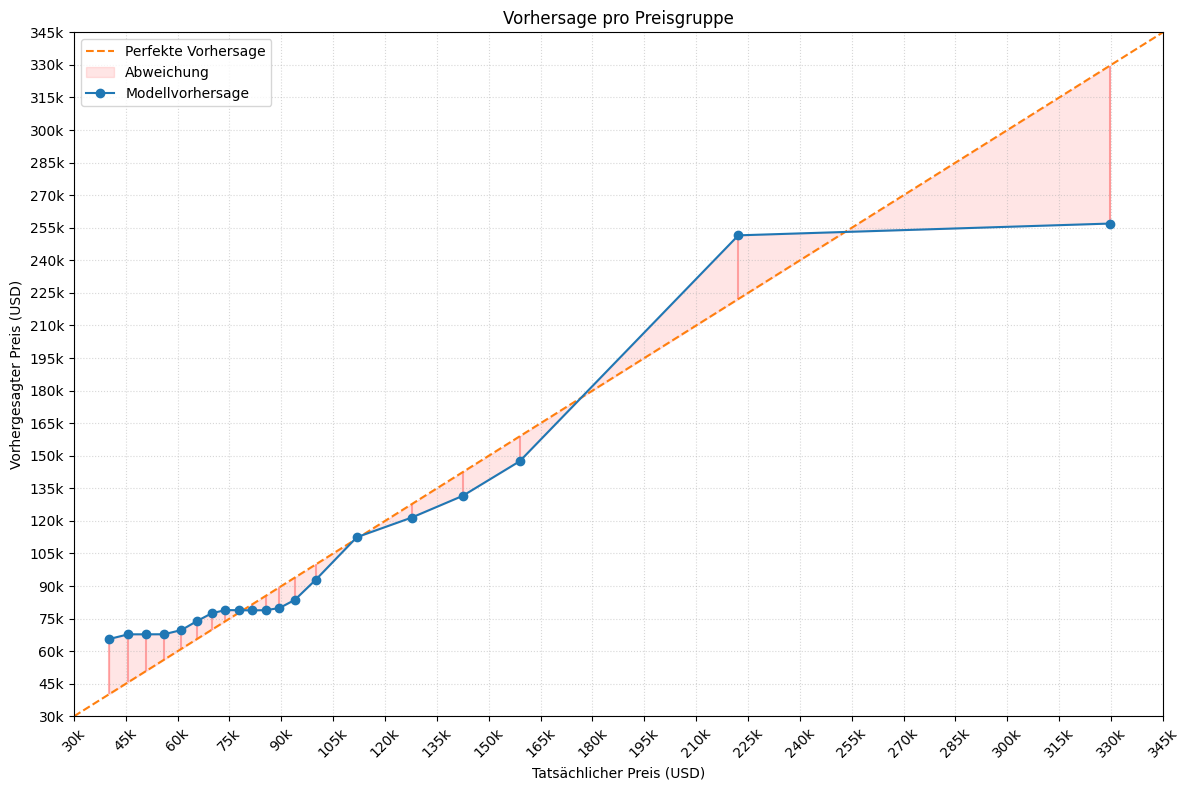

In [9]:
# Residuenanalyse: Wahrer Preis vs. Vorhergesagter Preis (in 20 Quantil-Gruppen)
residuals = y_test - y_pred

df_plot = pd.DataFrame({
    "true": y_test,
    "pred": y_pred
})

df_plot["bin"] = pd.qcut(df_plot["true"], q=20, duplicates="drop")

binned = df_plot.groupby("bin", observed=True).agg(
    true_mean=("true","mean"),
    pred_mean=("pred","mean")
).reset_index()

plt.figure(figsize=(12, 8))

mn, mx = 30000, 345000
plt.plot([mn, mx], [mn, mx], linestyle="--", color="tab:orange", label="Perfekte Vorhersage", zorder=2)

# Fehlerbereiche an den Punkten markieren
plt.vlines(binned["true_mean"], ymin=binned["true_mean"], ymax=binned["pred_mean"], 
           color='red', alpha=0.3, zorder=1)
plt.fill_between(binned["true_mean"], binned["true_mean"], binned["pred_mean"], 
                 color='red', alpha=0.1, label='Abweichung', zorder=1)

# Datenpunkte plotten
plt.plot(binned["true_mean"], binned["pred_mean"], marker="o", color="tab:blue", label="Modellvorhersage", zorder=3)

ticks = np.arange(30000, 360000, 15000)
labels = [f"{int(x/1000)}k" for x in ticks]

plt.xticks(ticks, labels, rotation=45) 
plt.yticks(ticks, labels)
plt.xlim(mn, mx)
plt.ylim(mn, mx)

# Beschriftungen
plt.xlabel("Tatsächlicher Preis (USD)")
plt.ylabel("Vorhergesagter Preis (USD)")
plt.title("Vorhersage pro Preisgruppe")

plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="upper left")

save_current_plot_mr()
plt.tight_layout()
plt.show()

- Referenzlinie: Diagonale = Perfekte Vorhersage.
- 20 Preis-Quantile zur segmentspezifischen Fehleranalyse.
- Preissegment (< 60k USD): Leichte Überschätzung
- Preissegment (75k – 180k USD): Vorhersage pendelt eng um die Linie -> sehr gute Modellpassung
- Preissegment (> 210k USD): Systematische Unterschätzung (Vorhersage deutliche Abweichung)
- Fehlende Luxus-Attribute zur Preisdifferenzierung

Übersprungen (Titel existiert bereits): 02 Residual Plot Analyse der Fehlerstreuung.png


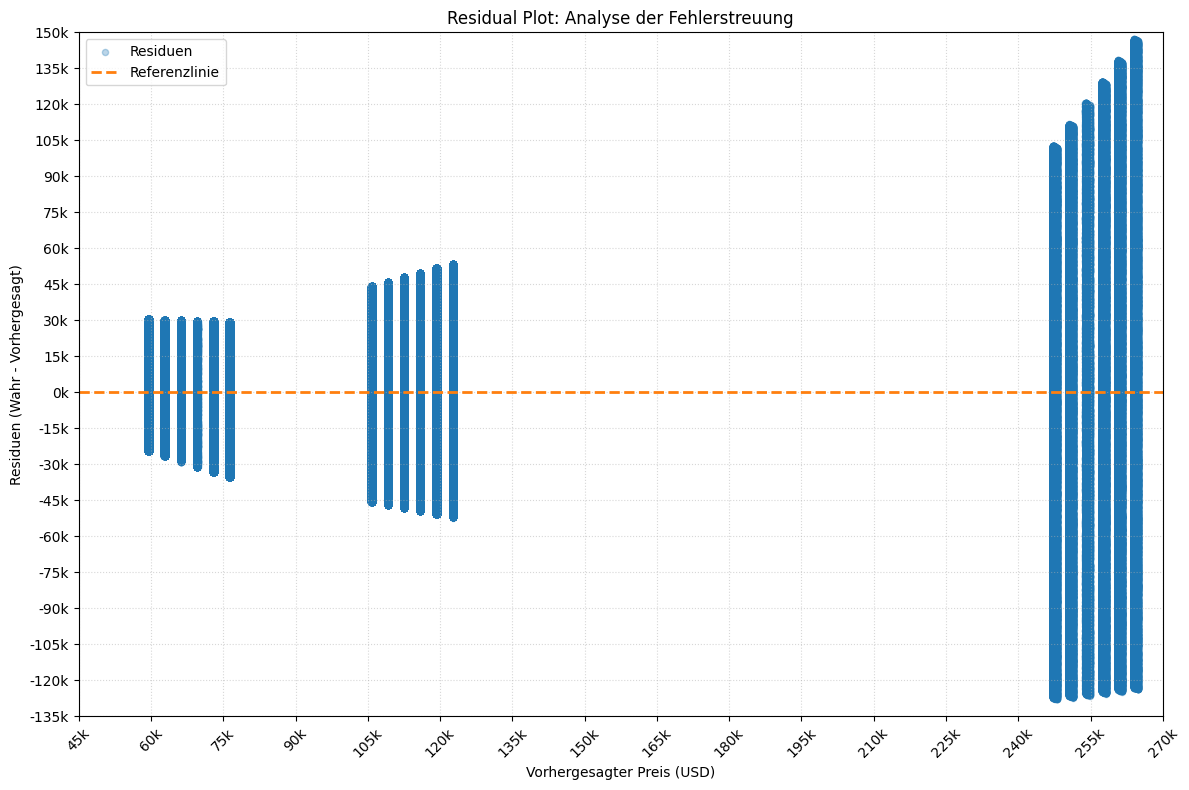

In [10]:
# Vorhersage vs. Residuen
plt.figure(figsize=(12, 8))

# Residuen plotten
plt.scatter(y_pred, residuals, alpha=0.3, color="tab:blue", s=20, label="Residuen")
plt.axhline(0, color="tab:orange", linestyle="--", linewidth=2, label="Referenzlinie")

x_min = (y_pred.min() // 15000) * 15000
x_max = (y_pred.max() // 15000 + 1) * 15000
ticks_x = np.arange(x_min, x_max + 15000, 15000)
plt.xticks(ticks_x, [f"{int(x/1000)}k" for x in ticks_x], rotation=45)


# Wir berechnen den Bereich basierend auf den minimalen/maximalen Residuen
y_min = (residuals.min() // 15000) * 15000
y_max = (residuals.max() // 15000 + 1) * 15000
ticks_y = np.arange(y_min, y_max + 15000, 15000)
plt.yticks(ticks_y, [f"{int(y/1000)}k" for y in ticks_y])

# Beschriftung & Layout
plt.xlabel("Vorhergesagter Preis (USD)")
plt.ylabel("Residuen (Wahr - Vorhergesagt)")
plt.title("Residual Plot: Analyse der Fehlerstreuung")
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="upper left")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

save_current_plot_mr()
plt.tight_layout()
plt.show()

- Referenzlinie: fehlerfreie Vorhersage
- Verteilung: uufällige Streuung
- Preissegment 60k–125k: Hohe Dichte nah an 0 -> Modell stabil
- Preissegment >240k: massive vertikale Streuung -> Modell unzuverlässig
- Fehler steigt proportional
- Datenlücken: fehlende Testdaten zwischen 135k und 240k USD

Übersprungen (Titel existiert bereits): 03 Häufigkeitsverteilung der Residuen.png


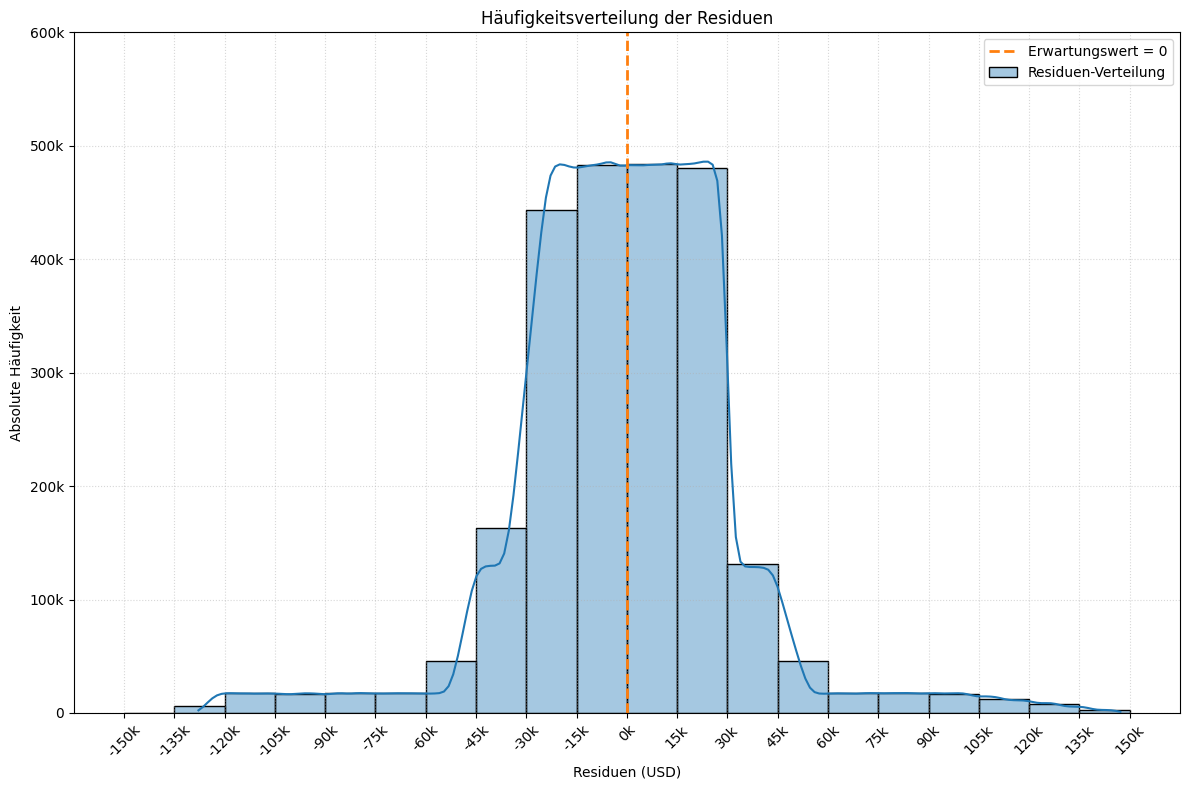

In [11]:
# Histogramm der Residuen
plt.figure(figsize=(12, 8))

# Histogramm mit 15k-Balkenbreite
sns.histplot(residuals, binwidth=15000, binrange=(-150000, 150000), 
             kde=True, color="tab:blue", alpha=0.4, edgecolor="black", label="Residuen-Verteilung")

# Referenzlinie
plt.axvline(0, color="tab:orange", linestyle="--", linewidth=2, label="Erwartungswert = 0")

x_ticks = np.arange(-150000, 150001, 15000)
plt.xticks(x_ticks, [f"{int(x/1000)}k" for x in x_ticks], rotation=45)

y_vals = plt.gca().get_yticks()
plt.yticks(y_vals, [f"{int(y/1000)}k" if y != 0 else "0" for y in y_vals])

# Beschriftung
plt.xlabel("Residuen (USD)")
plt.ylabel("Absolute Häufigkeit")
plt.title("Häufigkeitsverteilung der Residuen")
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="upper right")

save_current_plot_mr()
plt.tight_layout()
plt.show()

- Residuen konzentrieren sich um den Wert 0
- Verteilung annähernd symmetrisch
- Keine starke Verzerrung der Verteilung erkennbar
- Keine ausgeprägte Ausreißerstruktur sichtbar

# Gesamtwertung

- Das Modell erklärt rund 77 % der Varianz des Basispreises
- Die Modellreihe stellt den dominierenden Preisfaktor dar
- Technische Merkmale wie Motorleistung oder Turbo haben geringere Effekte
- Multikollinearität ist nur teilweise vorhanden und beeinflusst die Modellstabilität nicht wesentlich
- Im oberen Preissegment zeigt sich eine leichte systematische Unterschätzung
- Insgesamt liefert das Modell eine robuste und plausibel interpretierbare Preisstruktur